# Data_Evaluation

## Classification

In [35]:
import sklearn.metrics as metrics

In [36]:
y_pred = [1, 0, 0, 1, 0]
y_true = [1, 0, 1, 1, 0]

acc = metrics.accuracy_score(y_true, y_pred)
print(acc)

0.8


#### Recall

In [37]:
y_pred = [1, 0, 0, 1, 0, 1, 2, 1, 2]
y_true = [1, 0, 1, 1, 0, 0, 1, 2, 2]

recall = metrics.recall_score(y_true, y_pred,average = "macro")
print(
    metrics.recall_score(y_true, y_pred,average = "macro"),
    metrics.recall_score(y_true, y_pred,average = "micro"),
    metrics.recall_score(y_true, y_pred,average = "weighted"),
    metrics.recall_score(y_true, y_pred,average = None),
    # metrics.recall_score(y_true, y_pred,average = "binary")
)

0.5555555555555555 0.5555555555555556 0.5555555555555556 [0.66666667 0.5        0.5       ]


#### f1_score

In [38]:
metrics.f1_score(
    y_true,
    y_pred,
    average = "macro"
)

0.5555555555555555

#### confusion_matrix

In [39]:
y_true = [0, 0, 0, 1, 1, 1]
y_pred = [0, 0, 1, 0, 1, 1]

tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 2
FP: 1
FN: 1
TP: 2


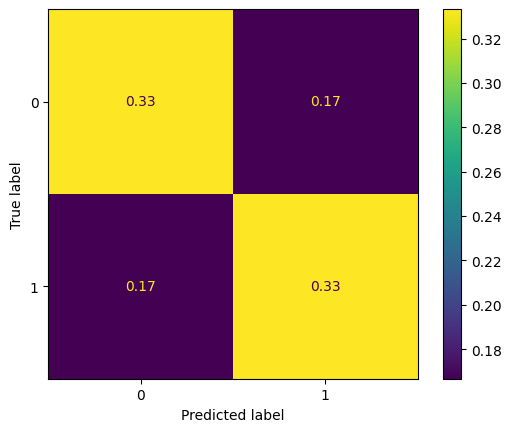

In [40]:
metrics.confusion_matrix(
    y_true = y_true,
    y_pred = y_pred,
    labels = [2,0]
)

metrics.ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    normalize = "all"
)

#### classification_report

In [41]:
print(metrics.classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



### Probability Indicators

In [47]:
import sklearn.datasets as datasets
import sklearn.model_selection as model_selection
import sklearn.preprocessing as preprocessing
import sklearn.linear_model as linear_model
import sklearn.metrics as metrics
import sklearn.pipeline as pipeline

X, y = datasets.load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("model", linear_model.LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)

y_proba = pipe.predict_proba(X_test)
print(pipe.classes_, y_proba[:5], sep = "\n-----\n")

[0 1]
-----
[[3.10179769e-02 9.68982023e-01]
 [9.99647982e-01 3.52018216e-04]
 [4.40588468e-01 5.59411532e-01]
 [6.10542466e-02 9.38945753e-01]
 [8.24508132e-01 1.75491868e-01]]


In [55]:
fpr, tpr, thres = metrics.roc_curve(y_test, y_proba[:,1])
print("fpr: ", fpr)
print("tpr: ", tpr)
print("thres: ", thres)

fpr:  [0.         0.         0.         0.01886792 0.01886792 1.        ]
tpr:  [0.         0.01111111 0.87777778 0.87777778 1.         1.        ]
thres:  [           inf 9.99999403e-01 9.00281691e-01 8.92930774e-01
 3.83064095e-01 5.31086312e-23]


#### ROC_Curve_Display

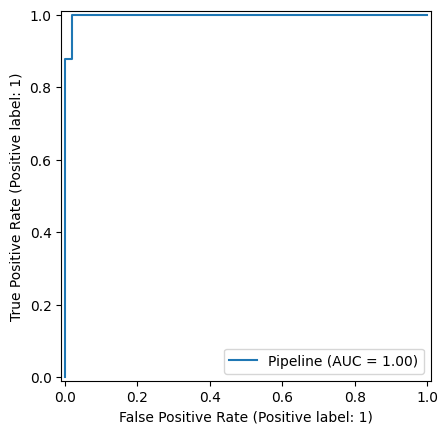

In [67]:
import matplotlib.pyplot as plt

metrics.RocCurveDisplay.from_estimator(
    pipe,
    X_test,
    y_test,
    pos_label=1,
)
plt.show()
plt.close()

## Regression